In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words=open('names.txt', 'r').read().splitlines()
print(words[:8:])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033


In [4]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
def build_dataset(words):
    block_size=3  #no. of elements in our context used to predict the next char 
    X,Y=[],[]
    for w in words:
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix] #updating last (3rd) element in context block


    X=torch.tensor(X)
    Y =torch.tensor(Y)
    print(X.shape, X.dtype, Y.shape, Y.dtype)

torch.Size([228146, 3]) torch.int64 torch.Size([228146]) torch.int64


In [18]:
g=torch.Generator().manual_seed(2147483647)

#initializing 2-d embeddings for all 27 of our characters
C=torch.randn((27,2),generator=g)

#creating hyperparamters
W1=torch.randn((6,100),generator=g)
b1=torch.randn((100),generator=g)

W2=torch.randn((100,27),generator=g)
b2=torch.randn((27),generator=g)

In [19]:
emb=C[X]  #extracting embeddings of samples stored in X
print("emb shape:",emb.shape,"\n")

h=torch.tanh(emb.view(-1,6)@ W1 + b1 )      #calculating 2nd layer
print("h shape:",h.shape,"\n",h)

logits=h @ W2 +b2                           #calculating 3rd layer
print("logits shape:",logits.shape,"\n",logits)

emb shape: torch.Size([228146, 3, 2]) 

h shape: torch.Size([228146, 100]) 
 tensor([[-0.9348,  1.0000,  0.9258,  ...,  0.9786, -0.1926,  0.9515],
        [ 0.2797,  0.9997,  0.7675,  ...,  0.9929,  0.9992,  0.9981],
        [-0.9960,  1.0000, -0.8694,  ..., -0.5159, -1.0000, -0.0069],
        ...,
        [-0.4849,  0.9972, -0.6418,  ..., -0.9641,  0.9996,  0.9873],
        [-0.9318,  0.9926, -0.9841,  ..., -0.8989, -0.9938,  0.5930],
        [-0.9736,  0.3844, -0.8744,  ..., -0.5093,  0.9998, -0.9975]])
logits shape: torch.Size([228146, 27]) 
 tensor([[  2.0191,  -0.5013,  13.3706,  ...,  10.2469,   2.8311,   9.2402],
        [ -6.9784,   0.8382,   9.4671,  ...,   5.7656,   4.1368,  12.4966],
        [  4.1821,  -3.6009,  17.0966,  ...,   6.5224, -10.4342,  -1.5205],
        ...,
        [ -5.8335,   0.0515,   0.8027,  ..., -10.3916,  -2.5706,  -1.6157],
        [ -1.6369,  -7.4065,   8.9311,  ...,  -5.8148,  -9.0827,   0.6466],
        [  1.0493, -15.2429,  -3.2347,  ..., -12.1904, 

In [32]:
loss=F.cross_entropy(logits,Y)  #Y contains all the actual labels of our samples in X
loss

tensor(2.4029, grad_fn=<NllLossBackward0>)

In [21]:
#backward pass
parameters=[C,W1,b1,W2,b2]
for p in parameters:
    p.requires_grad=True

lossarr=[]    

In [28]:

#training on mini batch
for i in range(10000):
    ix=torch.randint(0,X.shape[0],(100,))
    emb=C[X[ix]]
    h=torch.tanh(emb.view(-1,6)@ W1 +b1)  #(32,100)
    logits=h @ W2 +b2    #(32,27)
    loss=F.cross_entropy(logits,Y[ix])

    #gradient descent
    for p in parameters:
        p.grad =None
    loss.backward()

    for p in parameters:
        p.data+= -0.1 * p.grad
    lossarr.append(loss.item()) 
print(loss.item())         

2.253016471862793


In [29]:
#noting convergence with each iteration
for i,loss in enumerate(lossarr):
    print(i,loss)
    

0 21.78839111328125
1 17.442848205566406
2 14.699427604675293
3 14.009552001953125
4 14.555985450744629
5 12.851537704467773
6 15.152233123779297
7 12.29063606262207
8 11.356836318969727
9 11.645286560058594
10 10.900896072387695
11 10.11942195892334
12 9.863799095153809
13 9.049084663391113
14 8.646587371826172
15 9.90612506866455
16 8.71635627746582
17 10.71780014038086
18 7.929890155792236
19 9.393513679504395
20 8.293517112731934
21 9.626633644104004
22 7.258471488952637
23 8.276878356933594
24 7.238210678100586
25 9.016242027282715
26 7.527297496795654
27 7.71543025970459
28 7.523747444152832
29 6.933204174041748
30 7.171454429626465
31 6.8863983154296875
32 6.684225082397461
33 6.143285751342773
34 6.01437520980835
35 6.148798942565918
36 6.766331672668457
37 6.0457658767700195
38 5.195251941680908
39 6.629784107208252
40 6.191679000854492
41 7.138881206512451
42 4.654399871826172
43 6.047135829925537
44 5.801886081695557
45 4.973211765289307
46 5.466946601867676
47 4.84965229034

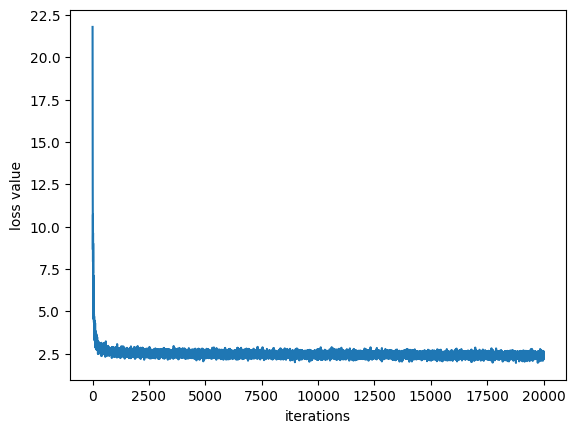

In [30]:
plt.plot(range((len(lossarr))),lossarr)
plt.xlabel("iterations")
plt.ylabel("loss value")
plt.show()

In [31]:
#loss on the whole dataset after mini batch optimization
emb=C[X]
h=torch.tanh(emb.view(-1,6) @ W1 +b1)
logits= h @ W2 + b2
loss=F.cross_entropy(logits,Y)
print(loss.item())


2.402867078781128


In [ ]:
#splitting the dataset intro train(80%), dev(10%),test(10%)
import random
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
Xtr,Ytr=build_dataset